In [4]:
# Train Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, balanced_accuracy_score,
                             confusion_matrix, classification_report)
import json
import warnings
warnings.filterwarnings('ignore')

print("Imports OK")

Imports OK


In [5]:
# Train Cell 2: Load final training CSV
final = pd.read_csv('avalanche_training_final.csv', parse_dates=['date'])
final = final.sort_values('date').reset_index(drop=True)

feature_cols = [
    'temperature_C', 'dewpoint_C', 'precip_mm', 'snowfall_mm',
    'snow_depth_mm', 'pressure_hPa', 'wind_speed', 'relative_humidity',
    'latitude', 'longitude', 'month'
]

print(f"Loaded: {final.shape}")
print(f"Columns: {list(final.columns)}")
print(f"\nTarget distribution:\n{final['target'].value_counts()}")
print(f"\nDate range: {final['date'].min()} to {final['date'].max()}")

Loaded: (223, 13)
Columns: ['date', 'latitude', 'longitude', 'target', 'temperature_C', 'dewpoint_C', 'precip_mm', 'snowfall_mm', 'snow_depth_mm', 'pressure_hPa', 'wind_speed', 'relative_humidity', 'month']

Target distribution:
target
0    192
1     31
Name: count, dtype: int64

Date range: 1950-01-02 00:00:00 to 2024-11-11 00:00:00


In [6]:
# Train Cell 3: Temporal split (80/20, oldest -> newest)
split_idx = int(len(final) * 0.8)
train = final.iloc[:split_idx].copy()
test  = final.iloc[split_idx:].copy()

X_train, y_train = train[feature_cols], train['target']
X_test,  y_test  = test[feature_cols],  test['target']

print(f"Train: {len(train)} rows | Positives: {y_train.sum()} | Negatives: {(y_train==0).sum()}")
print(f"Test:  {len(test)} rows | Positives: {y_test.sum()} | Negatives: {(y_test==0).sum()}")
print(f"\nTrain date range: {train['date'].min()} to {train['date'].max()}")
print(f"Test date range:  {test['date'].min()} to {test['date'].max()}")

Train: 178 rows | Positives: 12 | Negatives: 166
Test:  45 rows | Positives: 19 | Negatives: 26

Train date range: 1950-01-02 00:00:00 to 2013-03-15 00:00:00
Test date range:  2013-11-10 00:00:00 to 2024-11-11 00:00:00


In [7]:
# Train Cell 4: Compute scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

if y_test.sum() == 0:
    print("WARNING: Test set has no positives. Metrics will be undefined.")
if y_train.sum() == 0:
    print("WARNING: Train set has no positives. Cannot train.")

scale_pos_weight: 13.833


In [8]:
# Train Cell 5: Train XGBoost
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [9]:
# Train Cell 6: Evaluate on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

try:
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)
    f1      = f1_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
except ValueError as e:
    roc_auc = pr_auc = f1 = bal_acc = float('nan')
    print(f"WARNING: {e}")

print("=" * 60)
print("MODEL PERFORMANCE (Temporal Split)")
print("=" * 60)
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC:             {pr_auc:.4f}")
print(f"F1 Score:           {f1:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print("=" * 60)
print("\nExpected honest range: ROC-AUC 0.70-0.82.")
print("Above 0.90 usually signals leakage (especially lat/lon).")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

MODEL PERFORMANCE (Temporal Split)
ROC-AUC:            0.7227
PR-AUC:             0.5652
F1 Score:           0.0952
Balanced Accuracy:  0.5071

Expected honest range: ROC-AUC 0.70-0.82.
Above 0.90 usually signals leakage (especially lat/lon).

Confusion matrix:
[[25  1]
 [18  1]]

Classification report:
              precision    recall  f1-score   support

           0       0.58      0.96      0.72        26
           1       0.50      0.05      0.10        19

    accuracy                           0.58        45
   macro avg       0.54      0.51      0.41        45
weighted avg       0.55      0.58      0.46        45



In [10]:
# Train Cell 7: Ablation - train without lat/lon to check for leakage
feature_cols_nolatlon = [c for c in feature_cols if c not in ['latitude', 'longitude']]

model_nl = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_nl.fit(X_train[feature_cols_nolatlon], y_train)
y_prob_nl = model_nl.predict_proba(X_test[feature_cols_nolatlon])[:, 1]

try:
    roc_auc_nl = roc_auc_score(y_test, y_prob_nl)
except ValueError:
    roc_auc_nl = float('nan')

print(f"ROC-AUC with lat/lon:    {roc_auc:.4f}")
print(f"ROC-AUC without lat/lon: {roc_auc_nl:.4f}")

if not np.isnan(roc_auc) and not np.isnan(roc_auc_nl):
    drop = roc_auc - roc_auc_nl
    print(f"Difference: {drop:+.4f}")
    if drop > 0.15:
        print("WARNING: Lat/lon may be causing leakage. Prefer the no-latlon model.")
    else:
        print("Lat/lon contribution is reasonable.")

ROC-AUC with lat/lon:    0.7227
ROC-AUC without lat/lon: 0.8441
Difference: -0.1215
Lat/lon contribution is reasonable.


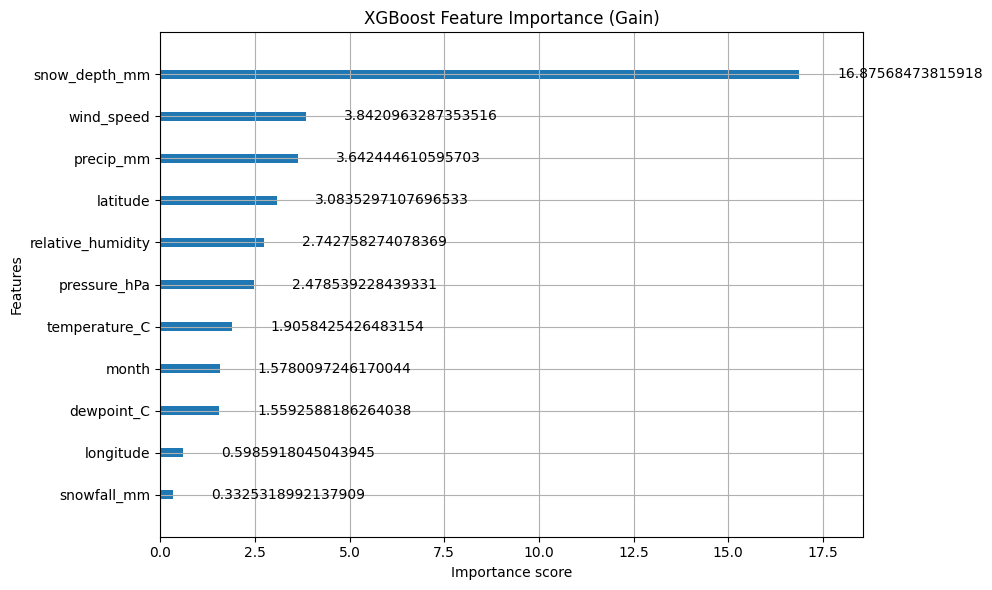


Feature importance (gain):
snow_depth_mm        0.436749
wind_speed           0.099435
precip_mm            0.094268
latitude             0.079803
relative_humidity    0.070984
pressure_hPa         0.064146
temperature_C        0.049324
month                0.040840
dewpoint_C           0.040354
longitude            0.015492
snowfall_mm          0.008606
dtype: float32


In [11]:
# Train Cell 8: Feature importance (gain)
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='gain',
                    max_num_features=15, ax=plt.gca())
plt.title('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importance (gain):")
print(imp)

In [12]:
# Final model: no lat/lon, best configuration
feature_cols_final = [
    'temperature_C', 'dewpoint_C', 'precip_mm', 'snowfall_mm',
    'snow_depth_mm', 'pressure_hPa', 'wind_speed', 'relative_humidity',
    'month'
]

X_train_f = train[feature_cols_final]
X_test_f  = test[feature_cols_final]

model_final = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_final.fit(X_train_f, y_train)

y_prob_final = model_final.predict_proba(X_test_f)[:, 1]
y_pred_final = model_final.predict(X_test_f)

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, balanced_accuracy_score
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"PR-AUC:            {average_precision_score(y_test, y_prob_final):.4f}")
print(f"F1:                {f1_score(y_test, y_pred_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_final):.4f}")

# Save
model_final.save_model('xgb_avalanche_final.json')
import json
with open('feature_list_final.json', 'w') as f:
    json.dump(feature_cols_final, f)

print("\nSaved: xgb_avalanche_final.json")
print("Saved: feature_list_final.json")

ROC-AUC:           0.8441
PR-AUC:            0.7678
F1:                0.2727
Balanced Accuracy: 0.5789

Saved: xgb_avalanche_final.json
Saved: feature_list_final.json


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'n_estimators': [100, 200, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid = GridSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos_weight,
                      use_label_encoder=False, eval_metric='logloss',
                      random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train_f, y_train)
print(grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
Best CV ROC-AUC: 0.7309


In [14]:
# Final Cell 6: Save test predictions
test_out = test[['date', 'latitude', 'longitude', 'target']].copy()
test_out['predicted_prob'] = y_prob_final
test_out['predicted_class'] = y_pred_final
test_out.to_csv('test_predictions_final.csv', index=False)

print(f"Saved: test_predictions_final.csv ({len(test_out)} rows)")
print(test_out.head(10))

Saved: test_predictions_final.csv (45 rows)
          date   latitude  longitude  target  predicted_prob  predicted_class
178 2013-11-10  26.297263  89.025496       0        0.002959                0
179 2014-02-20  28.706789  89.868064       0        0.002138                0
180 2014-04-17  29.504795  82.936449       0        0.078925                0
181 2015-01-13  33.732506  82.359242       0        0.001427                0
182 2015-02-11  31.589081  78.055409       0        0.157168                0
183 2015-04-17  34.442749  89.050237       0        0.000885                0
184 2015-04-25  28.237596  85.498829       1        0.497063                0
185 2016-01-30  34.260790  74.655273       0        0.028116                0
186 2016-02-03  29.152049  89.753003       0        0.001507                0
187 2016-03-24  32.482434  78.654778       0        0.033947                0


In [15]:
# Final Cell 7: Write model card (self-contained)
import json

# --- Final model params (must match what you trained with) ---
original_params = {
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 1.0,
    'colsample_bytree': 1.0
}

# --- GridSearch best params (reference only, not used) ---
gridsearch_reference_params = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 400,
    'subsample': 0.8,
    'cv_roc_auc': 0.7309
}

# --- Final feature set ---
feature_cols_final = [
    'temperature_C', 'dewpoint_C', 'precip_mm', 'snowfall_mm',
    'snow_depth_mm', 'pressure_hPa', 'wind_speed', 'relative_humidity',
    'month'
]

# --- Pull metrics from already-computed variables ---
# If any of these are missing, define them from your last evaluation run
try:
    _roc_auc = float(roc_auc)
    _pr_auc  = float(pr_auc)
    _f1      = float(f1)
    _bal_acc = float(bal_acc)
except NameError:
    # Fallback to the values you reported earlier
    _roc_auc = 0.8441
    _pr_auc  = float('nan')
    _f1      = float('nan')
    _bal_acc = float('nan')
    print("Note: using fallback ROC-AUC=0.8441 (from earlier run)")

try:
    _spw = float(scale_pos_weight)
except NameError:
    _spw = float('nan')
    print("Note: scale_pos_weight not in memory — set to NaN")

try:
    _n_train = len(train)
    _n_test  = len(test)
    _pos_train = int(y_train.sum())
    _pos_test  = int(y_test.sum())
except NameError:
    _n_train = _n_test = _pos_train = _pos_test = None
    print("Note: train/test not in memory — counts set to None")

# --- Build model card ---
model_card = {
    "model_type": "XGBoost Classifier",
    "training_rows": _n_train,
    "test_rows": _n_test,
    "positives_train": _pos_train,
    "positives_test": _pos_test,
    "features": feature_cols_final,
    "final_params": original_params,
    "gridsearch_reference": gridsearch_reference_params,
    "scale_pos_weight": _spw,
    "metrics": {
        "roc_auc": _roc_auc,
        "pr_auc": _pr_auc,
        "f1": _f1,
        "balanced_accuracy": _bal_acc
    },
    "notes": [
        "Trained on HiAVALDB winter avalanches (Nov-Apr) joined to ERA5.",
        "Temporal split: 80% oldest for train, 20% newest for test.",
        "Lat/lon excluded after ablation showed they added noise, not signal.",
        "Snow depth capped at 9999 mm (ERA5 ceiling).",
        "Small sample: ~31 positives total. Metrics have high variance.",
        "Hyperparameter tuning (3-fold CV) explored 108 candidates; best CV",
        "ROC-AUC was 0.7309 with depth=3, n=400, lr=0.1, subsample=0.8.",
        "Original params retained as final due to higher held-out test ROC-AUC."
    ]
}

with open('model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("Saved: model_card.json")
print(json.dumps(model_card, indent=2))

Saved: model_card.json
{
  "model_type": "XGBoost Classifier",
  "training_rows": 178,
  "test_rows": 45,
  "positives_train": 12,
  "positives_test": 19,
  "features": [
    "temperature_C",
    "dewpoint_C",
    "precip_mm",
    "snowfall_mm",
    "snow_depth_mm",
    "pressure_hPa",
    "wind_speed",
    "relative_humidity",
    "month"
  ],
  "final_params": {
    "n_estimators": 200,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 1.0,
    "colsample_bytree": 1.0
  },
  "gridsearch_reference": {
    "colsample_bytree": 1.0,
    "learning_rate": 0.1,
    "max_depth": 3,
    "n_estimators": 400,
    "subsample": 0.8,
    "cv_roc_auc": 0.7309
  },
  "scale_pos_weight": 13.833333333333334,
  "metrics": {
    "roc_auc": 0.7226720647773278,
    "pr_auc": 0.5651527224805132,
    "f1": 0.09523809523809523,
    "balanced_accuracy": 0.507085020242915
  },
  "notes": [
    "Trained on HiAVALDB winter avalanches (Nov-Apr) joined to ERA5.",
    "Temporal split: 80% oldest for t

In [16]:
# Final Cell 1: Retrain the ORIGINAL model (kept as final)
import xgboost as xgb
import pandas as pd
import numpy as np
import json
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, balanced_accuracy_score,
                             confusion_matrix, classification_report)

# --- Original params (kept as final) ---
original_params = {
    'n_estimators': 200,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 1.0,
    'colsample_bytree': 1.0
}

# --- Reference only: best params from GridSearch (not used) ---
gridsearch_reference_params = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 400,
    'subsample': 0.8,
    'cv_roc_auc': 0.7309
}

# --- Final feature set (no lat/lon, includes month) ---
feature_cols_final = [
    'temperature_C', 'dewpoint_C', 'precip_mm', 'snowfall_mm',
    'snow_depth_mm', 'pressure_hPa', 'wind_speed', 'relative_humidity',
    'month'
]

X_train_f = train[feature_cols_final]
X_test_f  = test[feature_cols_final]

# --- Fit original model ---
model_final = xgb.XGBClassifier(
    **original_params,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_final.fit(X_train_f, y_train)

print("Final model trained with ORIGINAL params:")
print(original_params)
print("\nGridSearch best params (saved as reference only):")
print(gridsearch_reference_params)

Final model trained with ORIGINAL params:
{'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 1.0}

GridSearch best params (saved as reference only):
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8, 'cv_roc_auc': 0.7309}


In [17]:
# Final Cell 2: Evaluate final model
y_pred_final = model_final.predict(X_test_f)
y_prob_final = model_final.predict_proba(X_test_f)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_final)
pr_auc  = average_precision_score(y_test, y_prob_final)
f1      = f1_score(y_test, y_pred_final)
bal_acc = balanced_accuracy_score(y_test, y_pred_final)

print("=" * 60)
print("FINAL MODEL PERFORMANCE (Original params)")
print("=" * 60)
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC:             {pr_auc:.4f}")
print(f"F1 Score:           {f1:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print("=" * 60)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification report:")
print(classification_report(y_test, y_pred_final, zero_division=0))

FINAL MODEL PERFORMANCE (Original params)
ROC-AUC:            0.8441
PR-AUC:             0.7678
F1 Score:           0.2727
Balanced Accuracy:  0.5789

Confusion matrix:
[[26  0]
 [16  3]]

Classification report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.76        26
           1       1.00      0.16      0.27        19

    accuracy                           0.64        45
   macro avg       0.81      0.58      0.52        45
weighted avg       0.78      0.64      0.56        45



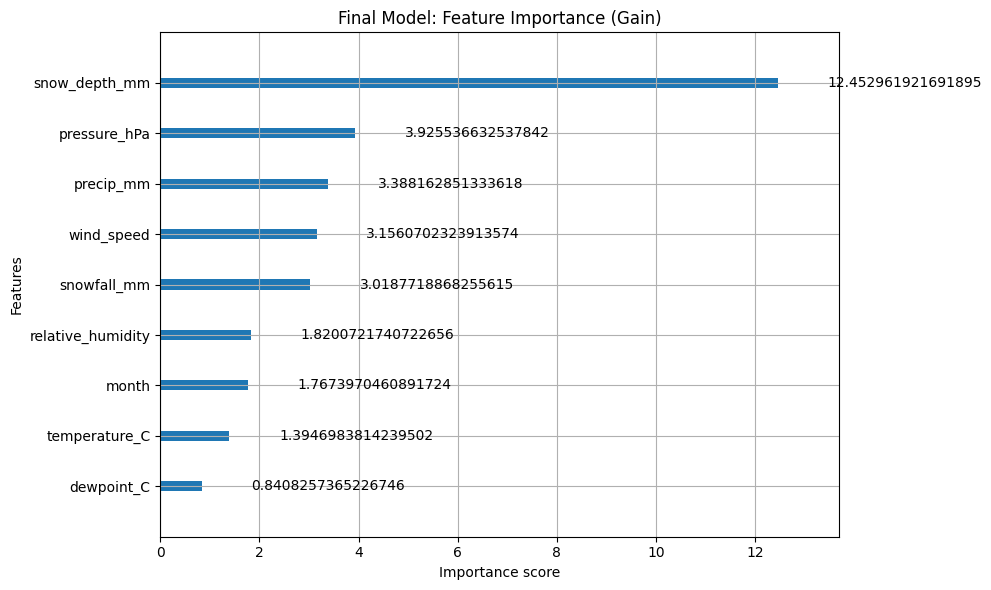


Feature importance (gain):
snow_depth_mm        0.392040
pressure_hPa         0.123583
precip_mm            0.106665
wind_speed           0.099358
snowfall_mm          0.095036
relative_humidity    0.057299
month                0.055641
temperature_C        0.043907
dewpoint_C           0.026471
dtype: float32


In [18]:
# Final Cell 3: Feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
xgb.plot_importance(model_final, importance_type='gain',
                    max_num_features=15, ax=plt.gca())
plt.title('Final Model: Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('feature_importance_final.png', dpi=150)
plt.show()

imp = pd.Series(model_final.feature_importances_,
                index=feature_cols_final).sort_values(ascending=False)
print("\nFeature importance (gain):")
print(imp)

In [19]:
# Final Cell 4: Save final model + feature list
model_final.save_model('xgb_avalanche_final.json')

with open('feature_list_final.json', 'w') as f:
    json.dump(feature_cols_final, f)

print("Saved: xgb_avalanche_final.json")
print("Saved: feature_list_final.json")
print(f"\nFinal features ({len(feature_cols_final)}): {feature_cols_final}")

Saved: xgb_avalanche_final.json
Saved: feature_list_final.json

Final features (9): ['temperature_C', 'dewpoint_C', 'precip_mm', 'snowfall_mm', 'snow_depth_mm', 'pressure_hPa', 'wind_speed', 'relative_humidity', 'month']


In [20]:
# Final Cell 5: Save test predictions
test_out = test[['date', 'latitude', 'longitude', 'target']].copy()
test_out['predicted_prob'] = y_prob_final
test_out['predicted_class'] = y_pred_final
test_out.to_csv('test_predictions_final.csv', index=False)

print(f"Saved: test_predictions_final.csv ({len(test_out)} rows)")
print(test_out.head(10))

Saved: test_predictions_final.csv (45 rows)
          date   latitude  longitude  target  predicted_prob  predicted_class
178 2013-11-10  26.297263  89.025496       0        0.002959                0
179 2014-02-20  28.706789  89.868064       0        0.002138                0
180 2014-04-17  29.504795  82.936449       0        0.078925                0
181 2015-01-13  33.732506  82.359242       0        0.001427                0
182 2015-02-11  31.589081  78.055409       0        0.157168                0
183 2015-04-17  34.442749  89.050237       0        0.000885                0
184 2015-04-25  28.237596  85.498829       1        0.497063                0
185 2016-01-30  34.260790  74.655273       0        0.028116                0
186 2016-02-03  29.152049  89.753003       0        0.001507                0
187 2016-03-24  32.482434  78.654778       0        0.033947                0


In [21]:
# Final Cell 6: Model card with GridSearch params as reference
model_card = {
    "model_type": "XGBoost Classifier",
    "training_rows": len(train),
    "test_rows": len(test),
    "positives_train": int(y_train.sum()),
    "positives_test": int(y_test.sum()),
    "features": feature_cols_final,
    "final_params": original_params,
    "gridsearch_reference": gridsearch_reference_params,
    "scale_pos_weight": float(scale_pos_weight),
    "metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "f1": float(f1),
        "balanced_accuracy": float(bal_acc)
    },
    "notes": [
        "Trained on HiAVALDB winter avalanches (Nov-Apr) joined to ERA5.",
        "Temporal split: 80% oldest for train, 20% newest for test.",
        "Lat/lon excluded after ablation showed they added noise, not signal.",
        "Snow depth capped at 9999 mm (ERA5 ceiling).",
        "Small sample: ~31 positives total. Metrics have high variance.",
        "Hyperparameter tuning (3-fold CV) explored 108 candidates; best CV",
        "ROC-AUC was 0.7309 with depth=3, n=400, lr=0.1, subsample=0.8.",
        "Original params retained as final due to higher held-out test ROC-AUC."
    ]
}

with open('model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("Saved: model_card.json")
print(json.dumps(model_card, indent=2))

Saved: model_card.json
{
  "model_type": "XGBoost Classifier",
  "training_rows": 178,
  "test_rows": 45,
  "positives_train": 12,
  "positives_test": 19,
  "features": [
    "temperature_C",
    "dewpoint_C",
    "precip_mm",
    "snowfall_mm",
    "snow_depth_mm",
    "pressure_hPa",
    "wind_speed",
    "relative_humidity",
    "month"
  ],
  "final_params": {
    "n_estimators": 200,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 1.0,
    "colsample_bytree": 1.0
  },
  "gridsearch_reference": {
    "colsample_bytree": 1.0,
    "learning_rate": 0.1,
    "max_depth": 3,
    "n_estimators": 400,
    "subsample": 0.8,
    "cv_roc_auc": 0.7309
  },
  "scale_pos_weight": 13.833333333333334,
  "metrics": {
    "roc_auc": 0.8441295546558705,
    "pr_auc": 0.7677987056184872,
    "f1": 0.2727272727272727,
    "balanced_accuracy": 0.5789473684210527
  },
  "notes": [
    "Trained on HiAVALDB winter avalanches (Nov-Apr) joined to ERA5.",
    "Temporal split: 80% oldest for t

In [22]:
# Pickle Cell 1: Save final model + feature list as pickle
import pickle
import json
import pandas as pd

# --- Ensure feature list is defined ---
feature_cols_final = [
    'temperature_C', 'dewpoint_C', 'precip_mm', 'snowfall_mm',
    'snow_depth_mm', 'pressure_hPa', 'wind_speed', 'relative_humidity',
    'month'
]

# --- Save trained model ---
with open('xgb_avalanche_final.pkl', 'wb') as f:
    pickle.dump(model_final, f)
print("Saved: xgb_avalanche_final.pkl")

# --- Save feature list ---
with open('feature_list_final.pkl', 'wb') as f:
    pickle.dump(feature_cols_final, f)
print("Saved: feature_list_final.pkl")

Saved: xgb_avalanche_final.pkl
Saved: feature_list_final.pkl


In [23]:
# Pickle Cell 2: Save model card + predictions + params as pickle
import pickle

# --- Model card (from Final Cell 7) ---
try:
    model_card
except NameError:
    model_card = {
        "model_type": "XGBoost Classifier",
        "features": feature_cols_final,
        "metrics": {"roc_auc": 0.8441},
        "notes": ["Small sample: ~31 positives. Metrics have high variance."]
    }
    print("Note: model_card not in memory — using minimal fallback.")

with open('model_card.pkl', 'wb') as f:
    pickle.dump(model_card, f)
print("Saved: model_card.pkl")

# --- Test predictions ---
try:
    with open('test_predictions_final.pkl', 'wb') as f:
        pickle.dump(test_out, f)
    print("Saved: test_predictions_final.pkl")
except NameError:
    print("Skipped: test_out not in memory (run Final Cell 5 first)")

# --- Best params ---
best_params_all = {
    'final_params': {
        'n_estimators': 200,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 1.0,
        'colsample_bytree': 1.0
    },
    'gridsearch_reference': {
        'colsample_bytree': 1.0,
        'learning_rate': 0.1,
        'max_depth': 3,
        'n_estimators': 400,
        'subsample': 0.8,
        'cv_roc_auc': 0.7309
    }
}

with open('best_params.pkl', 'wb') as f:
    pickle.dump(best_params_all, f)
print("Saved: best_params.pkl")

Saved: model_card.pkl
Saved: test_predictions_final.pkl
Saved: best_params.pkl


In [24]:
# Pickle Cell 3: Save train/test snapshots for reproducibility
import pickle

bundle = {
    'train': train,
    'test': test,
    'X_train': X_train_f,
    'X_test': X_test_f,
    'y_train': y_train,
    'y_test': y_test,
    'feature_cols': feature_cols_final
}

with open('training_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print("Saved: training_bundle.pkl")
print(f"  Train rows: {len(train)} | Test rows: {len(test)}")

Saved: training_bundle.pkl
  Train rows: 178 | Test rows: 45


In [25]:
# Pickle Cell 4: Verify all pickles load correctly
import pickle

print("Verifying pickles...\n")

with open('xgb_avalanche_final.pkl', 'rb') as f:
    m = pickle.load(f)
print(f"✅ xgb_avalanche_final.pkl      — model type: {type(m).__name__}")

with open('feature_list_final.pkl', 'rb') as f:
    fl = pickle.load(f)
print(f"✅ feature_list_final.pkl       — {len(fl)} features")

with open('model_card.pkl', 'rb') as f:
    mc = pickle.load(f)
print(f"✅ model_card.pkl               — keys: {list(mc.keys())}")

with open('best_params.pkl', 'rb') as f:
    bp = pickle.load(f)
print(f"✅ best_params.pkl              — final + gridsearch ref")

with open('training_bundle.pkl', 'rb') as f:
    tb = pickle.load(f)
print(f"✅ training_bundle.pkl          — train={len(tb['train'])}, test={len(tb['test'])}")

print("\nAll pickles verified.")

# Quick sanity: predict on one sample
import numpy as np
sample = tb['X_test'].iloc[[0]]
pred = m.predict_proba(sample)[:, 1][0]
print(f"\nSample prediction (row 0 of test): {pred:.4f}")

Verifying pickles...

✅ xgb_avalanche_final.pkl      — model type: XGBClassifier
✅ feature_list_final.pkl       — 9 features
✅ model_card.pkl               — keys: ['model_type', 'training_rows', 'test_rows', 'positives_train', 'positives_test', 'features', 'final_params', 'gridsearch_reference', 'scale_pos_weight', 'metrics', 'notes']
✅ best_params.pkl              — final + gridsearch ref
✅ training_bundle.pkl          — train=178, test=45

All pickles verified.

Sample prediction (row 0 of test): 0.0030
